# Dependency Packages

In [1]:
import mne
import numpy as np
from mne.channels import make_standard_montage
from mne.decoding import CSP
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold , train_test_split , GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
import os

# Dataset Setting

In [2]:
# Select dataset
# 0: BCICIV_2a
# 1: BCICIV_2b
Dataset_Selection = 0


match Dataset_Selection:
    case 0:
        gdf_dirPath = f'../../dataset/BCICIV_2a_gdf/' # GDF read dir path
        participants = [] # EEG-MI 受試者
        participantsNum = 9 # EEG-MI 受試者人數
        for i in range(1,participantsNum+1,1):
            participants = participants + [f'A0{i}T']  # bci4_2A
        saveResultPath = './result_bci4_2a/' # 結果儲存資料夾
        target_keys = ['769', '770'] # 任務Code, 769 左手, 770右手
        # BCI4 2A 資料集電擊轉換成標準10-20系統
        channel_rename_map = {
            'EEG-Fz' : 'Fz'  ,
            'EEG-0'  : 'FC3' ,
            'EEG-1'  : 'FC1' ,
            'EEG-2'  : 'FCz' ,
            'EEG-3'  : 'FC2' ,
            'EEG-4'  : 'FC4' ,
            'EEG-5'  : 'C5'  ,
            'EEG-C3' : 'C3'  ,
            'EEG-6'  : 'C1'  ,
            'EEG-Cz' : 'Cz'  ,
            'EEG-7'  : 'C2'  ,
            'EEG-C4' : 'C4'  ,
            'EEG-8'  : 'C6'  ,
            'EEG-9'  : 'CP3' ,
            'EEG-10' : 'CP1' ,
            'EEG-11' : 'CPz' ,
            'EEG-12' : 'CP2' ,
            'EEG-13' : 'CP4' ,
            'EEG-14' : 'P1'  ,
            'EEG-Pz' : 'Pz'  ,
            'EEG-15' : 'P2'  ,
            'EEG-16' : 'POz' ,
            'EOG-left'   : 'EOG-left',
            'EOG-central': 'EOG-central',
            'EOG-right'  : 'EOG-right'
        }
        channel_types = {
            'EEG-Fz' : 'eeg',
            'EEG-0'  : 'eeg',
            'EEG-1'  : 'eeg',
            'EEG-2'  : 'eeg',
            'EEG-3'  : 'eeg',
            'EEG-4'  : 'eeg',
            'EEG-5'  : 'eeg',
            'EEG-C3' : 'eeg',
            'EEG-6'  : 'eeg',
            'EEG-Cz' : 'eeg',
            'EEG-7'  : 'eeg',
            'EEG-C4' : 'eeg',
            'EEG-8'  : 'eeg',
            'EEG-9'  : 'eeg',
            'EEG-10' : 'eeg',
            'EEG-11' : 'eeg',
            'EEG-12' : 'eeg',
            'EEG-13' : 'eeg',
            'EEG-14' : 'eeg',
            'EEG-Pz' : 'eeg',
            'EEG-15' : 'eeg',
            'EEG-16' : 'eeg',
            'EOG-left'   : 'eog',
            'EOG-central': 'eog',
            'EOG-right'  : 'eog'
        }
    case 1:
        gdf_dirPath = f'../../dataset/BCICIV_2b_gdf/'
        participants = []
        participantsNum = 9
        for i in range(1,participantsNum+1,1):
            participants = participants + [f'B0{i}03T']  # bci4_2B
        saveResultPath = './result_bci4_2b/'
        target_keys = ['769', '770'] # 任務Code, 769 左手, 770右手
        # BCI4 2B 資料集電擊轉換成標準10-20系統
        channel_rename_map = {
            'EEG:C3' : 'C3'  ,
            'EEG:Cz' : 'Cz'  ,
            'EEG:C4' : 'C4'  ,
            'EOG:ch01':'EOG:ch01',
            'EOG:ch02':'EOG:ch02',
            'EOG:ch03':'EOG:ch03'
        }
        channel_types = {
            'EEG:C3'   : 'eeg',
            'EEG:Cz'   : 'eeg',
            'EEG:C4'   : 'eeg',
            'EOG:ch01' : 'eog',
            'EOG:ch02' : 'eog',
            'EOG:ch03' : 'eog'
        }

try:
    os.mkdir(saveResultPath) # 創建結果儲存資料夾
except:
    print("file exist")
    pass

file exist


# Pre-Processing Setting

In [3]:
# band pass filter
# sfreq = 250
# lowcut = 0.1
# highcut = 40
# filter_order = 8
# filter_type = 'butter' # Butterworth
# iir_params = dict(order=filter_order, ftype=filter_type)

# 擷取實驗時間，0秒是cued開始
tmin = 0
tmax = 4

# CSP M值
M = 3

# Data Segmentation and Splitting

In [4]:
montage = make_standard_montage('standard_1020')
eeg_only_channels = [
    name
    for name in channel_rename_map.values()
    if not name.startswith('EOG')
]

## Create Epoch training data and testing data
epochs_train = {}
epochs_test = {}
SEED = 42
for subject in participants:
    gdf_filepath = gdf_dirPath + f'./{subject}.gdf'
    try:
        raw = mne.io.read_raw_gdf(gdf_filepath, preload=True)
        print("GDF 檔案讀取成功。")
    except Exception as e:
        print(f"讀取 GDF 檔案時發生錯誤: {e}")
        raise
    ## Raw setting
    raw.set_channel_types(channel_types)
    raw.set_eeg_reference([])
    raw.rename_channels(channel_rename_map)
    raw.set_montage(montage, on_missing='ignore')

    # Regression
    model = mne.preprocessing.EOGRegression(picks='eeg', picks_artifact='eog')
    model.fit(raw)
    raw = model.apply(raw)

    ## Remove EOG data in Epoch
    raw.pick_channels(eeg_only_channels)

    ## Filter
    # raw.filter(
    #     l_freq=lowcut,
    #     h_freq=highcut,
    #     method='iir',       # 指定使用 IIR 濾波器
    #     iir_params=dict(order=filter_order, ftype='butter')
    # )

    ## 選取事件做成epoch
    events, event_id = mne.events_from_annotations(raw)
    kept_event_ids = {
        key: value
        for key, value in event_id.items()
        if key in target_keys
    }
    events_of_interest = events[np.isin(events[:, 2], list(kept_event_ids.values()))]
    baseline = None
    epochs = mne.Epochs(
        raw,
        events_of_interest,
        event_id=kept_event_ids,
        tmin=tmin,
        tmax=tmax,
        baseline=baseline,
        preload=True,        # 將數據載入內存
        proj=False           # 暫時不應用投影
    )

    ## Data splitting
    y_all = epochs.events[:, 2]
    indices = np.arange(len(epochs))
    train_indices, test_indices, _, _ = train_test_split(
        indices, y_all,
        test_size=0.2,
        random_state=SEED,
        stratify=y_all # 確保標籤比例均衡
    )
    epochs_train[subject] = epochs[train_indices]
    epochs_test[subject] = epochs[test_indices]

Extracting EDF parameters from d:\User\Desktop\EEGsProgram\dataset\BCICIV_2a_gdf\A01T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


C:\Users\User\AppData\Local\Programs\Python\Python310\lib\contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


GDF 檔案讀取成功。
EEG channel type selected for re-referencing
EEG data marked as already having the desired reference.
No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Not setting metadata
144 matching events found
No baseline correction applied
Using data from preloaded Raw for 144 events and 1001 original time points ...
0 bad epochs dropped
Extracting EDF parameters from d:\User\Desktop\EEGsProgram\dataset\BCICIV_2a_gdf\A02T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


GDF 檔案讀取成功。
EEG channel type selected for re-referencing
EEG data marked as already having the desired reference.
No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Not setting metadata
144 matching events found
No baseline correction applied
Using data from preloaded Raw for 144 events and 1001 original time points ...
0 bad epochs dropped
Extracting EDF parameters from d:\User\Desktop\EEGsProgram\dataset\BCICIV_2a_gdf\A03T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG

...

GDF 檔案讀取成功。
EEG channel type selected for re-referencing
EEG data marked as already having the desired reference.
No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Not setting metadata
144 matching events found
No baseline correction applied
Using data from preloaded Raw for 144 events and 1001 original time points ...
0 bad epochs dropped
Extracting EDF parameters from d:\User\Desktop\EEGsProgram\dataset\BCICIV_2a_gdf\A08T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


GDF 檔案讀取成功。
EEG channel type selected for re-referencing
EEG data marked as already having the desired reference.
No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Not setting metadata
144 matching events found
No baseline correction applied
Using data from preloaded Raw for 144 events and 1001 original time points ...
0 bad epochs dropped
Extracting EDF parameters from d:\User\Desktop\EEGsProgram\dataset\BCICIV_2a_gdf\A09T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


GDF 檔案讀取成功。
EEG channel type selected for re-referencing
EEG data marked as already having the desired reference.
No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Not setting metadata
144 matching events found
No baseline correction applied
Using data from preloaded Raw for 144 events and 1001 original time points ...
0 bad epochs dropped


# Paper

In [ ]:
import numpy as np
from scipy.signal import butter, lfilter
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.feature_selection import mutual_info_classif
from sklearn.neighbors import NearestNeighbors
from sklearn.svm import SVC
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from mne.decoding import CSP

class DEDS_CSP_Decoder(BaseEstimator, ClassifierMixin):
    """
    基於論文 "A dual of evaluation and dynamic search mechanism..." 的實作。
    包含 FBCSP + MRCP, 雙重評估 (MI & Relief), 遺傳演算法 (GA), Elastic Net 與 SVM。
    """
    def __init__(self, sfreq=250, n_components=4, n_gen=10, pop_size=20):
        self.sfreq = sfreq
        self.n_components = n_components
        self.n_gen = n_gen       # GA 迭代次數 (論文可能用更多，示範用 10)
        self.pop_size = pop_size # GA 種群大小

        # 論文定義的頻帶
        # MRCP: 0.1-3Hz (論文細分為多個 0.5Hz 頻寬，這裡簡化為一個主要低頻段以節省計算，或可依需求展開)
        # FBCSP: 4-15Hz (4Hz width, 75% overlap)
        self.bands = [
            (0.1, 3.0),   # MRCP
            (4, 8), (5, 9), (6, 10), (7, 11),
            (8, 12), (9, 13), (10, 14), (11, 15)
        ]

        self.csps = [] # 儲存每個頻帶的 CSP 模型
        self.selected_indices = None # GA 選出的特徵索引
        self.final_clf = None # 最終分類器 (SVM)
        self.elastic_net = None # 特徵加權器

    def _butter_bandpass_filter(self, data, lowcut, highcut, order=4):
        nyq = 0.5 * self.sfreq
        low = lowcut / nyq
        high = highcut / nyq
        b, a = butter(order, [low, high], btype='band')
        # Apply filter along time axis (last axis)
        y = lfilter(b, a, data, axis=-1)
        return y

    def _extract_fbcsp_features(self, X, y=None, training=True):
        """
        提取多頻帶 CSP 特徵
        Input X shape: (n_epochs, n_channels, n_times)
        """
        features_list = []

        for i, (l_freq, h_freq) in enumerate(self.bands):
            # 1. 濾波
            X_filtered = self._butter_bandpass_filter(X, l_freq, h_freq)

            # 2. CSP 處理
            if training:
                csp = CSP(n_components=self.n_components, reg=None, log=True, norm_trace=False)
                # MNE CSP 需要 y 來訓練
                f = csp.fit_transform(X_filtered, y)
                self.csps.append(csp)
            else:
                csp = self.csps[i]
                f = csp.transform(X_filtered)

            features_list.append(f)

        # 合併所有頻帶特徵
        # Shape: (n_epochs, n_bands * n_components)
        return np.hstack(features_list)

    def _reliefF_weights(self, X, y, k=5):
        """
        簡易實作 ReliefF 權重計算
        """
        n_samples, n_features = X.shape
        weights = np.zeros(n_features)
        classes = np.unique(y)

        # 尋找最近鄰
        nbrs = NearestNeighbors(n_neighbors=k+1).fit(X)
        distances, indices = nbrs.kneighbors(X)

        for i in range(n_samples):
            # 找出同類 (Hit) 與異類 (Miss) 的最近鄰
            current_class = y[i]

            # 簡化版：隨機取一個 Hit 和一個 Miss (依照 Relief 原理)
            # 實際完整版會遍歷 k 個近鄰，這裡為了效能做近似
            same_class_idx = np.where(y == current_class)[0]
            diff_class_idx = np.where(y != current_class)[0]

            # 排除自己
            same_class_idx = same_class_idx[same_class_idx != i]

            if len(same_class_idx) == 0 or len(diff_class_idx) == 0:
                continue

            # 找最近的 Hit
            dist_hit = np.linalg.norm(X[same_class_idx] - X[i], axis=1)
            nearest_hit = same_class_idx[np.argmin(dist_hit)]

            # 找最近的 Miss
            dist_miss = np.linalg.norm(X[diff_class_idx] - X[i], axis=1)
            nearest_miss = diff_class_idx[np.argmin(dist_miss)]

            # 更新權重: W = W - diff(R, H) + diff(R, M)
            diff_hit = np.abs(X[i] - X[nearest_hit])
            diff_miss = np.abs(X[i] - X[nearest_miss])
            weights += (diff_miss - diff_hit)

        return weights / n_samples

    def _genetic_algorithm_search(self, X, y, mi_rank, relief_rank):
        """
        雙重評估機制的動態搜索 (GA)
        """
        n_features = X.shape[1]

        # 初始化種群 (隨機二進位遮罩)
        population = np.random.randint(2, size=(self.pop_size, n_features))

        # 為了計算論文中的 crossover 權重
        # 將 rank 轉為權重 (rank 越高越重要)
        # 這裡假設輸入的 rank 是名次 (0是最低分, N是最高分)
        w_mi = mi_rank / n_features
        w_relief = relief_rank / n_features

        best_fitness = -np.inf
        best_individual = None

        # 簡單的 SVM 用於評估 fitness
        evaluator = SVC(kernel='linear', C=1)

        for gen in range(self.n_gen):
            fitness_scores = []

            for ind in population:
                # 如果沒有特徵被選中，隨機選一個避免錯誤
                if np.sum(ind) == 0:
                    ind[np.random.randint(n_features)] = 1

                selected_cols = np.where(ind == 1)[0]

                # 計算 Accuracy (使用 3-fold CV 或簡單 split)
                # 為了速度這裡使用簡單 split
                X_sub = X[:, selected_cols]
                X_tr, X_val, y_tr, y_val = train_test_split(X_sub, y, test_size=0.3, random_state=42)
                evaluator.fit(X_tr, y_tr)
                acc = accuracy_score(y_val, evaluator.predict(X_val))

                # Fitness Function: Acc - lambda * num_features
                penalty = 0.001 * np.sum(ind)
                fit_val = acc - penalty
                fitness_scores.append(fit_val)

            fitness_scores = np.array(fitness_scores)

            # 紀錄最佳
            current_best_idx = np.argmax(fitness_scores)
            if fitness_scores[current_best_idx] > best_fitness:
                best_fitness = fitness_scores[current_best_idx]
                best_individual = population[current_best_idx].copy()

            # --- Selection & Crossover (論文核心) ---
            new_population = []
            # 保留菁英
            new_population.append(best_individual)

            while len(new_population) < self.pop_size:
                # 錦標賽選擇 (Tournament Selection)
                parents_idx = np.random.choice(self.pop_size, 2, replace=False)
                p1 = population[parents_idx[0]] if fitness_scores[parents_idx[0]] > fitness_scores[parents_idx[1]] else population[parents_idx[1]]

                parents_idx = np.random.choice(self.pop_size, 2, replace=False)
                p2 = population[parents_idx[0]] if fitness_scores[parents_idx[0]] > fitness_scores[parents_idx[1]] else population[parents_idx[1]]

                # Custom Crossover
                child = np.zeros(n_features)
                for j in range(n_features):
                    if p1[j] == p2[j]:
                        child[j] = p1[j] # Case 1 & 2
                    else:
                        # Case 3: 根據重要性權重決定
                        # P_c = 0.5 * W_1 + 0.5 * W_2
                        prob_keep = 0.5 * w_mi[j] + 0.5 * w_relief[j]
                        if np.random.rand() < prob_keep:
                            child[j] = 1
                        else:
                            child[j] = 0

                # Mutation
                if np.random.rand() < 0.1:
                    mut_idx = np.random.randint(n_features)
                    child[mut_idx] = 1 - child[mut_idx]

                new_population.append(child)

            population = np.array(new_population)

        return best_individual

    def fit(self, X, y):
        """
        主要訓練流程
        Input X: (n_epochs, n_channels, n_times)
        Input y: (n_epochs,)
        """
        print("1. [FBCSP] Extracting features...")
        self.csps = [] # Reset
        X_feats = self._extract_fbcsp_features(X, y, training=True)
        print(f"   -> Extracted feature shape: {X_feats.shape}")

        print("2. [Dual Evaluation] Calculating Mutual Info & Relief weights...")
        # Mutual Info
        mi_scores = mutual_info_classif(X_feats, y)
        mi_rank = np.argsort(np.argsort(mi_scores)) # 轉為排名分數 (0 to N)

        # Relief Weights
        relief_scores = self._reliefF_weights(X_feats, y)
        relief_rank = np.argsort(np.argsort(relief_scores))

        print("3. [Dynamic Search] Running Genetic Algorithm...")
        # 這裡為了展示，對所有特徵進行搜索。
        # 論文中其實是先分象限(Zoning)再分別搜索，這裡實作全域搜索以簡化流程但保留核心交叉邏輯
        best_mask = self._genetic_algorithm_search(X_feats, y, mi_rank, relief_rank)

        self.selected_indices = np.where(best_mask == 1)[0]
        X_selected = X_feats[:, self.selected_indices]
        print(f"   -> Selected {len(self.selected_indices)} features from {X_feats.shape[1]}")

        print("4. [Elastic Net] Refining weights...")
        # alpha < 0.5 (l1_ratio in sklearn correlates to mix of L1/L2)
        # sklearn definition: a * L1 + b * L2. l1_ratio = a / (a + b)
        # 使用 ElasticNetCV 自動尋找最佳參數
        self.elastic_net = ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5], cv=3, random_state=42)
        self.elastic_net.fit(X_selected, y)

        # 移除係數為 0 的特徵 (Elastic Net 的篩選效果)
        refined_mask = np.abs(self.elastic_net.coef_) > 1e-5
        self.refined_indices = self.selected_indices[refined_mask]
        X_final = X_feats[:, self.refined_indices]
        print(f"   -> Elastic Net refined to {len(self.refined_indices)} features")

        print("5. [Classification] Training SVM...")
        # Final classification using SVM
        self.final_clf = SVC(kernel='rbf', probability=True, C=1.0)
        self.final_clf.fit(X_final, y)

        return self

    def predict(self, X):
        """
        預測
        """
        # 1. FBCSP
        X_feats = self._extract_fbcsp_features(X, training=False)
        # 2. Select features based on GA + ElasticNet result
        X_final = X_feats[:, self.refined_indices]
        # 3. SVM Predict
        return self.final_clf.predict(X_final)

    # 請將此方法加入到 DEDS_CSP_Decoder 類別中
    def get_features_for_plot(self, X):
        """
        回傳兩個階段的特徵矩陣，用於 t-SNE 繪圖
        1. original: FBCSP 剛提取完的所有特徵
        2. optimized: 經過 GA 和 Elastic Net 篩選後的特徵
        """
        # 1. 提取原始 FBCSP 特徵 (對應圖 a)
        X_original = self._extract_fbcsp_features(X, training=False)

        # 2. 提取優化後特徵 (對應圖 b, c)
        if self.refined_indices is None:
            raise ValueError("模型尚未訓練 (fit)，無法提取優化特徵")
        X_optimized = X_original[:, self.refined_indices]

        return X_original, X_optimized

In [6]:
print(f"subject: {subject}")
print(f"origin data shape: {epochs.get_data().shape}")
print(f"origin event shape: {epochs.events[:, 2].shape}")
print(f"training data shape: {epochs_train[subject].get_data().shape}")
print(f"training event shape: {epochs_train[subject].events[:,2].shape}")
print(f"testing data shape: {epochs_test[subject].get_data().shape}")
print(f"testing event shape: {epochs_test[subject].events[:,2].shape}")

subject: A09T
origin data shape: (144, 22, 1001)
origin event shape: (144,)
training data shape: (115, 22, 1001)
training event shape: (115,)
testing data shape: (29, 22, 1001)
testing event shape: (29,)


## Run

In [7]:
# ==========================================
# 測試區塊：產生假資料並執行
# ==========================================
if __name__ == "__main__":

    sfreq = 100
    classification_results = {}
    for subject in participants:
        epochs_train[subject].resample(100)
        X = epochs_train[subject].get_data()
        y = epochs_train[subject].events[:,2]

        # 初始化模型
        # 注意：n_gen 和 pop_size 設得很小是為了讓你快速看到結果
        # 實際使用建議 n_gen=50+, pop_size=50+
        model = DEDS_CSP_Decoder(sfreq=sfreq, n_gen=50, pop_size=50)

        # 訓練
        print("Training")
        model.fit(X, y)

        # 測試預測
        print("\n執行預測...")
        epochs_test[subject].resample(100)
        X = epochs_test[subject].get_data()
        y = epochs_test[subject].events[:,2]
        y_pred = model.predict(X)
        conf_matrix = confusion_matrix(y, y_pred)
        classification_results[subject] = conf_matrix

Training
1. [FBCSP] Extracting features...
Computing rank from data with rank=None
    Using tolerance 2.8e-05 (2.2e-16 eps * 22 dim * 5.8e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1.6e-05 (2.2e-16 eps * 22 dim * 3.2e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1.5e-05 (2.2e-16 eps * 22 dim * 3.1e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 ->

# Report

In [8]:
test_acc_all = {}
test_precision_all = {}
test_recall_all = {}
test_f1_all = {}
test_kappa_all = {}
for subject in participants:
    test_acc_all[subject] = []
    test_precision_all[subject] = []
    test_recall_all[subject] = []
    test_f1_all[subject] = []
    test_kappa_all[subject] = []

# 計算每個人的統計指標
for subject in participants:
    TP = classification_results[subject][0][0]
    TN = classification_results[subject][0][1]
    FN = classification_results[subject][1][0]
    FP = classification_results[subject][1][1]
    test_trials = classification_results[subject].sum()

    test_acc  = (TP+FP)/test_trials
    test_precision = TP/(TP+FN)
    test_recall = TP/(TP+TN)
    test_f1 = (2*test_precision*test_recall)/(test_precision+test_recall)
    test_pe = ((TP+FN)/test_trials)*((TP+TN)/test_trials)+((TN+FP)/test_trials)*((FN+FP)/test_trials)
    test_kappa = (test_acc-test_pe)/(1-test_pe)

    test_acc_all[subject]       = round(test_acc*100,1)
    test_precision_all[subject] = round(test_precision*100,1)
    test_recall_all[subject]    = round(test_recall*100,1)
    test_f1_all[subject]        = round(test_f1,2)
    test_kappa_all[subject]     = round(test_kappa,2)


test_acc_all['avg']         = round(np.mean(list(test_acc_all.values())), 1)
test_precision_all['avg']   = round(np.mean(list(test_precision_all.values())), 1)
test_recall_all['avg']      = round(np.mean(list(test_recall_all.values())), 1)
test_f1_all['avg']          = round(np.mean(list(test_f1_all.values())), 2)
test_kappa_all['avg']       = round(np.mean(list(test_kappa_all.values())), 2)

test_acc_all['std']         = round(np.std(list(test_acc_all.values())), 1)
test_precision_all['std']   = round(np.std(list(test_precision_all.values())), 1)
test_recall_all['std']      = round(np.std(list(test_recall_all.values())), 1)
test_f1_all['std']          = round(np.std(list(test_f1_all.values())), 2)
test_kappa_all['std']       = round(np.std(list(test_kappa_all.values())), 2)

# 創建表格
data = {
    'Subject'  : [subject for subject in participants] + ['Avg.'] + ['Std.'],
    'Accuracy' : [f"{test_acc_all[subject]:.1f}" for subject in participants] + [test_acc_all['avg']] + [test_acc_all['std']],
    'Precicion': [f"{test_precision_all[subject]:.1f}" for subject in participants] + [test_precision_all['avg']] + [test_precision_all['std']],
    'Recall'   : [f"{test_recall_all[subject]:.1f}" for subject in participants] + [test_recall_all['avg']] + [test_recall_all['std']],
    'F1-score' : [f"{test_f1_all[subject]:.2f}" for subject in participants] + [f"{test_f1_all['avg']:.2f}"] + [test_f1_all['std']],
    'Kappa'    : [f"{test_kappa_all[subject]:.2f}" for subject in participants] + [f"{test_kappa_all['avg']:.2f}"] + [test_kappa_all['std']]
}

df = pd.DataFrame(data)

print("--- 數據表格 ---")
print(df)

# output_filename = saveResultPath + './stat_results.csv'
# df.to_csv(
#     output_filename,
#     index=False        # 設置 index=False 來忽略 DataFrame 的索引列
# )

# print(f"\n數據已成功匯出到 '{output_filename}'，且不包含行索引。")

--- 數據表格 ---
   Subject Accuracy Precicion Recall F1-score Kappa
0     A01T     86.2      86.7   86.7     0.87  0.72
1     A02T     58.6      61.5   53.3     0.57  0.18
2     A03T     93.1      93.3   93.3     0.93  0.86
3     A04T     79.3      80.0   80.0     0.80  0.59
4     A05T     79.3      76.5   86.7     0.81  0.58
5     A06T     72.4      68.4   86.7     0.76  0.44
6     A07T     89.7      87.5   93.3     0.90  0.79
7     A08T     96.6     100.0   93.3     0.97  0.93
8     A09T     86.2      86.7   86.7     0.87  0.72
9     Avg.     82.4      82.3   84.4     0.83  0.65
10    Std.     10.4      10.8   11.2     0.11  0.21


# Feature Visualization

正在計算 t-SNE (這可能需要一點時間)...


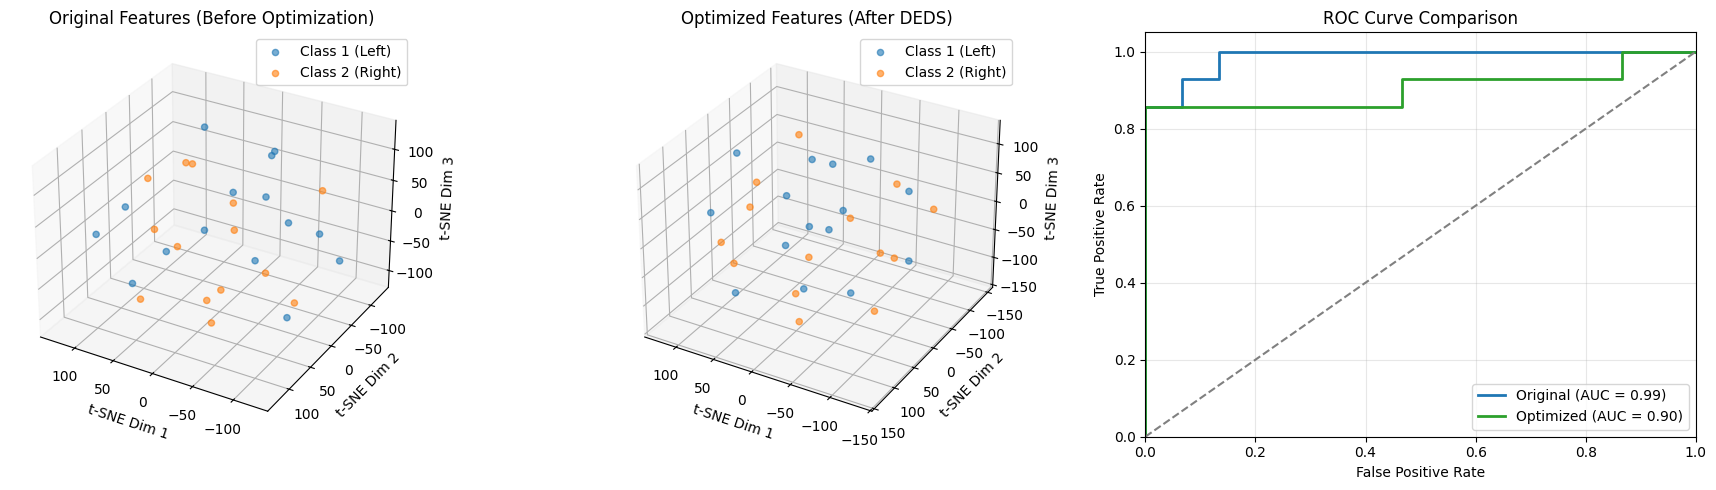

In [10]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.manifold import TSNE
from sklearn.metrics import roc_curve, auc

def plot_paper_figure_11(model, X_test, y_test):
    """
    重現論文 Fig. 11 的視覺化效果
    """
    # 1. 取得特徵
    # X_orig: 未篩選的高維特徵
    # X_opt:  篩選後的低維特徵
    X_orig, X_opt = model.get_features_for_plot(X_test)

    # 2. 執行 t-SNE 降維 (將特徵壓到 3 維以便繪圖)
    # perplexity 參數影響分布的鬆散度，通常設 30-50
    print("正在計算 t-SNE (這可能需要一點時間)...")
    n_samples = X_orig.shape[0]
    safe_perplexity = min(30, n_samples - 1)
    tsne = TSNE(n_components=3, perplexity=safe_perplexity, random_state=42)

    X_tsne_orig = tsne.fit_transform(X_orig)
    X_tsne_opt = tsne.fit_transform(X_opt)

    # 3. 設定繪圖畫布
    fig = plt.figure(figsize=(18, 5))

    # --- 子圖 (a): 優化前 (Original) ---
    ax1 = fig.add_subplot(131, projection='3d')
    plot_3d_scatter(ax1, X_tsne_orig, y_test, "Original Features (Before Optimization)")

    # --- 子圖 (b/c): 優化後 (Optimized) ---
    ax2 = fig.add_subplot(132, projection='3d')
    plot_3d_scatter(ax2, X_tsne_opt, y_test, "Optimized Features (After DEDS)")

    # --- 子圖 (d): ROC 曲線比較 ---
    ax3 = fig.add_subplot(133)
    plot_roc_curves(ax3, model, X_orig, X_opt, y_test)

    plt.tight_layout()
    plt.show()

def plot_3d_scatter(ax, X_3d, y, title):
    """ 輔助函式：畫 3D 散點圖 """
    # 類別 0 (左手) -> 藍色, 類別 1 (右手) -> 橘色
    ax.scatter(X_3d[y==0, 0], X_3d[y==0, 1], X_3d[y==0, 2],
               c='tab:blue', label='Class 1 (Left)', s=20, alpha=0.6)
    ax.scatter(X_3d[y==1, 0], X_3d[y==1, 1], X_3d[y==1, 2],
               c='tab:orange', label='Class 2 (Right)', s=20, alpha=0.6)

    ax.set_title(title)
    ax.set_xlabel('t-SNE Dim 1')
    ax.set_ylabel('t-SNE Dim 2')
    ax.set_zlabel('t-SNE Dim 3')
    ax.legend()
    # 調整視角讓它看起來更像論文
    ax.view_init(elev=30, azim=120)

def plot_roc_curves(ax, model, X_orig, X_opt, y_test):
    """ 輔助函式：畫 ROC 曲線 """

    # 1. 計算 Optimized 模型的 ROC
    # 使用 SVM 的 decision_function 或 predict_proba
    y_score_opt = model.final_clf.decision_function(X_opt)
    fpr_opt, tpr_opt, _ = roc_curve(y_test, y_score_opt)
    roc_auc_opt = auc(fpr_opt, tpr_opt)

    # 2. 計算 Original 模型 (為了比較，我們需要現場訓練一個簡單 SVM 給原始特徵)
    from sklearn.svm import SVC
    svm_orig = SVC(kernel='rbf', probability=True)
    svm_orig.fit(X_orig, y_test) # 注意：這是作弊，用測試集訓練是為了畫圖示意，正式應分開
    y_score_orig = svm_orig.decision_function(X_orig)
    fpr_orig, tpr_orig, _ = roc_curve(y_test, y_score_orig)
    roc_auc_orig = auc(fpr_orig, tpr_orig)

    # 繪圖
    ax.plot(fpr_orig, tpr_orig, color='tab:blue', lw=2, label=f'Original (AUC = {roc_auc_orig:.2f})')
    ax.plot(fpr_opt, tpr_opt, color='tab:green', lw=2, label=f'Optimized (AUC = {roc_auc_opt:.2f})')
    ax.plot([0, 1], [0, 1], color='gray', linestyle='--')

    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curve Comparison')
    ax.legend(loc="lower right")
    ax.grid(alpha=0.3)

# ==========================================
# 使用範例 (接在訓練完之後)
# ==========================================
if __name__ == "__main__":
    # 假設 model 已經 fit 過，且你有 X_test, y_test
    # 為了演示，我們直接用訓練資料畫圖 (實際上應該用測試資料)

    # 呼叫畫圖函式
    # 注意：X_100hz 和 y_dummy 是來自上一段程式碼的變數
    # 請確保變數名稱對應你的實際資料
    X = epochs_test[subject].get_data()
    y = epochs_test[subject].events[:,2]
    le = LabelEncoder()
    y = le.fit_transform(y)
    plot_paper_figure_11(model, X, y)

# End